In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import cv2
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch.nn.functional as F
from tqdm import tqdm

In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
    print(f"✅ Using GPU: {torch.cuda.get_device_name(0)}")
    print(f"🔥 GPU Memory Allocated: {torch.cuda.memory_allocated(0)/1024**3:.2f} GB")
else:
    print("❌ Using CPU")

✅ Using GPU: NVIDIA GeForce RTX 3060 Laptop GPU
🔥 GPU Memory Allocated: 0.00 GB


In [3]:
# ===============================
# 2. PATHS
# ===============================
BASE_DIR = r"C:\PartOfFASDD\Dataset"
IMG_DIR = os.path.join(BASE_DIR, "images")
LBL_DIR = os.path.join(BASE_DIR, "labels")

In [4]:
# ===============================
# 3. ENCODE TARGETS (YOLO → GRID)
# ===============================
def encode_targets(bboxes, labels, S=7, C=2):
    target = torch.zeros((S, S, 5 + C))

    for box, label in zip(bboxes, labels):
        x, y, w, h = box

        i = int(x * S)
        j = int(y * S)

        i = min(i, S - 1)
        j = min(j, S - 1)

        x_cell = x * S - i
        y_cell = y * S - j

        target[j, i, 0:4] = torch.tensor([x_cell, y_cell, w, h])
        target[j, i, 4] = 1
        target[j, i, 5 + int(label)] = 1

    return target


In [5]:
# ===============================
# 4. DATASET
# ===============================
class FireDataset(Dataset):
    def __init__(self, img_dir, label_dir):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.img_names = [f for f in os.listdir(img_dir) if f.endswith(('.jpg','.png','.jpeg'))]

        self.transform = A.Compose([
            A.Resize(416, 416),
            A.HorizontalFlip(p=0.5),
            A.RandomBrightnessContrast(p=0.2),
            ToTensorV2()
        ], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

    def __len__(self):
        return len(self.img_names)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_names[idx])
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        label_path = os.path.join(self.label_dir, os.path.splitext(self.img_names[idx])[0] + ".txt")

        bboxes = []
        class_labels = []

        if os.path.exists(label_path):
            with open(label_path) as f:
                for line in f.readlines():
                    cls, x, y, w, h = map(float, line.split())
                    bboxes.append([x, y, w, h])
                    class_labels.append(int(cls))

        if len(bboxes) > 0:
            transformed = self.transform(image=image, bboxes=bboxes, class_labels=class_labels)
            image = transformed['image'].float() / 255.0
            bboxes = np.array(transformed['bboxes'])
            class_labels = transformed['class_labels']

            bboxes = np.clip(bboxes, 0, 1)
            target = encode_targets(bboxes, class_labels)

        else:
            image = cv2.resize(image, (416,416)).transpose(2,0,1)
            image = torch.tensor(image, dtype=torch.float32) / 255.0
            target = torch.zeros((7,7,7))  # neither

        return image, target

In [6]:
# ===============================
# 5. MODEL (Mini YOLO)
# ===============================
class MiniYOLO(nn.Module):
    def __init__(self, S=7, C=2):
        super().__init__()
        self.S = S
        self.C = C

        self.backbone = nn.Sequential(
            nn.Conv2d(3,16,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d((7,7))
        )

        self.head = nn.Conv2d(128, 5+2, kernel_size=1)

    def forward(self, x):
        x = self.backbone(x)
        x = self.head(x)
        x = x.permute(0,2,3,1)
        return x

In [7]:
# ===============================
# 6. LOSS FUNCTION
# ===============================
def yolo_loss(pred, target):
    obj_mask = target[...,4] == 1
    noobj_mask = target[...,4] == 0

    box_loss = F.mse_loss(pred[..., :4][obj_mask], target[..., :4][obj_mask])

    obj_loss = F.binary_cross_entropy_with_logits(
        pred[...,4][obj_mask], target[...,4][obj_mask]
    )

    noobj_loss = F.binary_cross_entropy_with_logits(
        pred[...,4][noobj_mask], target[...,4][noobj_mask]
    )

    class_loss = F.cross_entropy(
        pred[...,5:][obj_mask],
        torch.argmax(target[...,5:][obj_mask], dim=-1)
    )

    return box_loss + obj_loss + 0.5*noobj_loss + class_loss

In [8]:
def compute_accuracy(pred, target):
    obj_mask = target[...,4] == 1
    
    if obj_mask.sum() == 0:
        return 0
    
    pred_classes = torch.argmax(pred[...,5:], dim=-1)
    true_classes = torch.argmax(target[...,5:], dim=-1)
    
    correct = (pred_classes[obj_mask] == true_classes[obj_mask]).sum().item()
    total = obj_mask.sum().item()
    
    return correct / total

In [9]:
def train():
    dataset = FireDataset(IMG_DIR, LBL_DIR)

    train_size = int(0.7 * len(dataset))
    val_size = int(0.15 * len(dataset))
    test_size = len(dataset) - train_size - val_size

    train_ds, val_ds, test_ds = random_split(dataset, [train_size, val_size, test_size])

    # Changed num_workers to 0 to prevent hanging/sluggishness on Windows Jupyter
    train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=0, pin_memory=True)
    val_loader   = DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=0)

    model = MiniYOLO().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)

    for epoch in range(10):
        # ================= TRAIN =================
        model.train()
        train_loss = 0
        train_acc = 0
        
        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}")

        for imgs, targets in loop:
            imgs = imgs.to(DEVICE)
            targets = targets.to(DEVICE)

            preds = model(imgs)
            loss = yolo_loss(preds, targets)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            acc = compute_accuracy(preds, targets)

            train_loss += loss.item()
            train_acc += acc

            loop.set_postfix(
                train_loss=loss.item(),
                train_acc=f"{acc*100:.1f}%"
            )

        train_loss /= len(train_loader)
        train_acc /= len(train_loader)

        # ================= VALIDATION =================
        model.eval()
        val_loss = 0
        val_acc = 0

        with torch.no_grad():
            for imgs, targets in val_loader:
                imgs = imgs.to(DEVICE)
                targets = targets.to(DEVICE)

                preds = model(imgs)
                loss = yolo_loss(preds, targets)

                acc = compute_accuracy(preds, targets)

                val_loss += loss.item()
                val_acc += acc

        val_loss /= len(val_loader)
        val_acc /= len(val_loader)

        # ================= PRINT =================
        print(f"\n📊 Epoch {epoch+1}")
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
        print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc*100:.2f}%")
        print("-"*50)

    return model, test_ds

In [10]:
model, test_ds = train()

Epoch 1: 100%|██████████| 1750/1750 [06:41<00:00,  4.36it/s, train_acc=80.0%, train_loss=1.31]  



📊 Epoch 1
Train Loss: 1.3856 | Train Acc: 80.79%
Val   Loss: 1.2741 | Val   Acc: 83.92%
--------------------------------------------------


Epoch 2: 100%|██████████| 1750/1750 [04:25<00:00,  6.60it/s, train_acc=87.5%, train_loss=1.24]  



📊 Epoch 2
Train Loss: 1.2375 | Train Acc: 84.58%
Val   Loss: 1.1940 | Val   Acc: 86.11%
--------------------------------------------------


Epoch 3: 100%|██████████| 1750/1750 [02:27<00:00, 11.88it/s, train_acc=85.0%, train_loss=1.06]  


...


📊 Epoch 8
Train Loss: 1.0197 | Train Acc: 89.35%
Val   Loss: 1.0196 | Val   Acc: 90.15%
--------------------------------------------------


Epoch 9: 100%|██████████| 1750/1750 [02:23<00:00, 12.19it/s, train_acc=89.5%, train_loss=1.11]  



📊 Epoch 9
Train Loss: 1.0117 | Train Acc: 89.84%
Val   Loss: 1.0016 | Val   Acc: 89.69%
--------------------------------------------------


Epoch 10: 100%|██████████| 1750/1750 [02:24<00:00, 12.12it/s, train_acc=85.7%, train_loss=1.21]  



📊 Epoch 10
Train Loss: 1.0070 | Train Acc: 89.68%
Val   Loss: 1.0056 | Val   Acc: 89.79%
--------------------------------------------------


In [11]:
import matplotlib.pyplot as plt

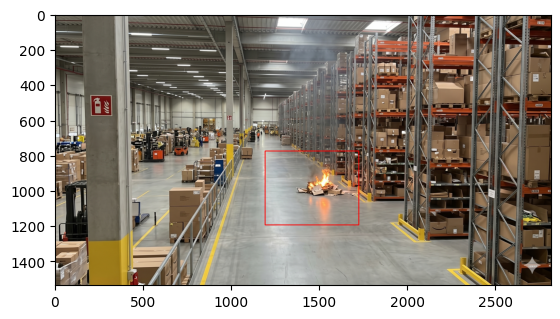

In [12]:
def predict_yolo(img_path, model, S=7):
    model.eval()
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h_orig, w_orig = img.shape[:2]
    
    # Preprocess
    img_input = cv2.resize(img_rgb, (416, 416)).transpose(2,0,1) / 255.0
    tensor = torch.tensor(img_input, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    
    with torch.no_grad():
        out = model(tensor) # Shape: (1, 7, 7, 7)
    
    # Get cell with highest objectness score
    conf_map = out[0, ..., 4]
    j, i = torch.unravel_index(torch.argmax(conf_map), (S, S))
    
    # Get prediction data
    box = out[0, j, i, 0:4] # x_cell, y_cell, w, h
    cls = torch.argmax(out[0, j, i, 5:])
    
    # Convert to pixel coordinates
    x_abs = (box[0] + i) / S * w_orig
    y_abs = (box[1] + j) / S * h_orig
    w_abs = box[2] * w_orig
    h_abs = box[3] * h_orig
    
    # Drawing
    x1, y1 = int(x_abs - w_abs/2), int(y_abs - h_abs/2)
    x2, y2 = int(x_abs + w_abs/2), int(y_abs + h_abs/2)
    cv2.rectangle(img, (x1,y1), (x2,y2), (0,0,255), 3)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.show()

# Run it
predict_yolo("C:/PartOfFASDD/testimg.png", model)

In [ ]:
# Save the model
torch.save(model.state_dict(), 'fire_detection_model.pt')
print("Model saved to fire_detection_model.pt")

Model saved to mini_yolo_model.pt
